<a href="https://colab.research.google.com/github/urnotirisfeng/AI/blob/main/Visualisation_TD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TD1

---

# EX1 :
1.   使用 Scikit-learn 提供的聚类算法对不同的数据集进行处理
2.   使用 Scikit-learn 提供的降维算法对不同的数据集进行处理


---





调用 load_digits() 时，会返回一个类似字典的对象

属性名

*   images ：原始图像数据，形状为 (n_samples, 8, 8)，也就是每个图像是 8x8 像素
*   data：展平后的图像数据，每张图变成了一个 64 维的向量（8×8=64），形状为 (n_samples, 64)
* target	每张图的真实标签（也就是这个手写数字实际代表的是几））
* target_names	标签的含义（0 到 9）

---



In [ ]:
# 使用 sklearn 中的 load_digits 函数加载数据集，并显示其形状（shape）
from sklearn.datasets import load_digits

# 加载数据
digits = load_digits()

# 显示数据形状
print("Images.shape:", digits.images.shape)
print("Data.shape :", digits.data.shape)
print("Target.shape:", digits.target.shape)

Images.shape: (1797, 8, 8)
Data.shape : (1797, 64)
Target.shape: (1797,)


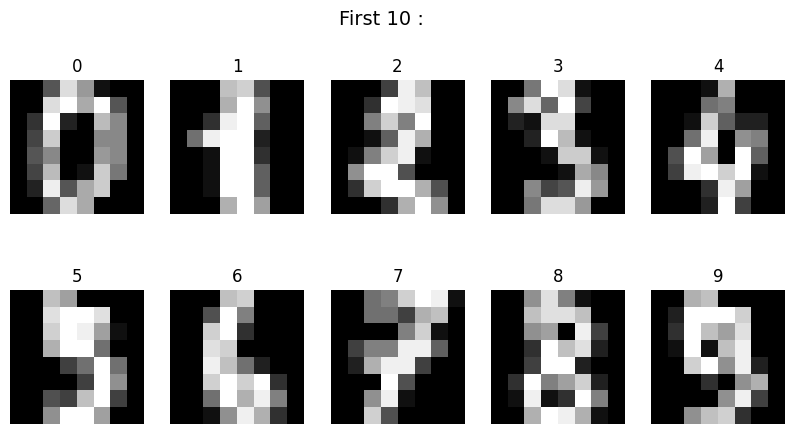

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for index in range(10): # 循环前十张图像
    plt.subplot(2, 5, index + 1)  # 意思是把整张图分成 1 行 10 列，然后我们当前画的是第 index+1 个位置的图

    plt.imshow(digits.images[index], cmap="gray", interpolation='nearest')
    # digits.images[index] 是第 index 张图的 8x8 像素矩阵
    # cmap=plt.cm.gray_r 使用灰度反转的配色方案（白底黑字） // or = gray 变成黑底白字
    # interpolation='nearest' 表示图像放大时使用最近邻插值，图像边缘更清晰

    plt.title(str(digits.target[index]))  # 设置标题为对应数字
    plt.axis('off')  # 不显示坐标轴

plt.suptitle("First 10 : ", fontsize=14)
plt.show()


3：使用课程中讲过的某种聚类算法（例如 KMeans），对数据集进行聚类。在这个问题中应该使用多少个簇（cluster）？
*  在**聚类（Clustering）**算法中，簇是指：一组在特征上彼此相似的数据点的集合
*   我们不告诉算法图片上的数字是什么（不使用标签），然后看它能不能自动分出不同的类别（聚类）




本题借助“灰度”来进行分类预测：

灰度（Grayscale）就是黑白图像中，每个像素点的亮度值。

最黑的地方是：黑色（灰度 = 0）

最亮的地方是：白色（灰度 = 最大值，通常是 255 或 16）

中间的灰色区域：灰度值在 0 和最大值之间

每张图被看作一个64维的点，KMeans在聚类时，会比较这些 64 维向量之间的距离。
比如：
图像 A = [0, 0, 0, 10, 15, ...]
图像 B = [0, 0, 1, 11, 14, ...]
由于它们的像素灰度分布很接近，那么它们之间的距离很小，KMeans 就会把它们聚在一起。

---



In [ ]:
# import KMeans
from sklearn.cluster import KMeans

# 分成10簇
n_clusters = 10

# 使用 KMeans 进行聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(digits.data)  # 训练模型

# 预测每个图像属于哪个簇
predicted_labels = kmeans.labels_

# 打印前20个图像的预测簇编号（不是数字标签，只是簇的编号）
print("First 10 images predict number：")
print(predicted_labels[:10])

First 10 images predict number：
[5 7 7 6 4 9 2 0 8 9]



---
4：显示一些图像样本及其聚类后预测的标签。

---



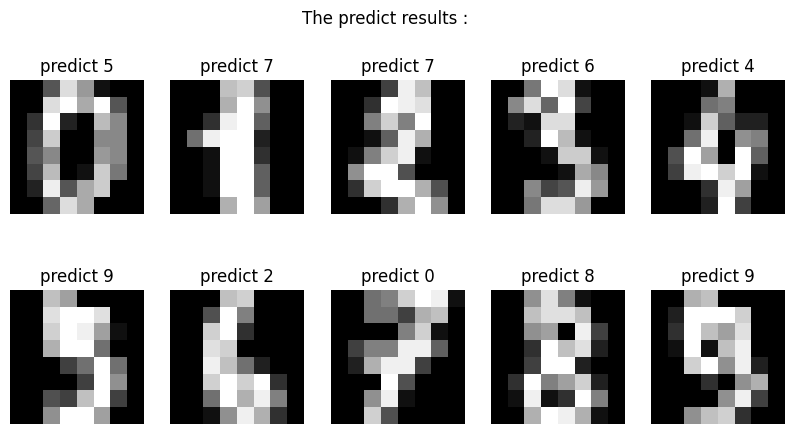

In [ ]:
# 加载数据
digits = load_digits()
X = digits.data
y_true = digits.target

# 使用上面训练的模型
kmeans = KMeans(n_clusters=10, random_state=42)
y_pred = kmeans.fit_predict(X)  # 得到预测的簇标签（不是实际数字）

# 显示前10张预测得图像，及其预测的聚类编号
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')  # 将64维向量还原为8x8图像
    ax.set_title(f"predict {y_pred[i]}")  # 标题为预测标签
    ax.axis('off')  # 不显示坐标轴

plt.suptitle("The predict results :")
plt.show()


---
5/ Afficher les centres des clusters trouvés


---


可视化KMeans聚类中心
在第五步中，我们：

取出 KMeans 聚类中每个簇的中心点
→ 每个中心是一个长度为 64 的向量（因为每张图像是 8×8 = 64 像素点）

把这些中心向量重塑（reshape）成 8x8 的图像矩阵
→ 这样我们就可以像普通图像一样显示它们了

把它们显示出来，一共会显示 10 张图（因为我们设定 n_clusters=10）

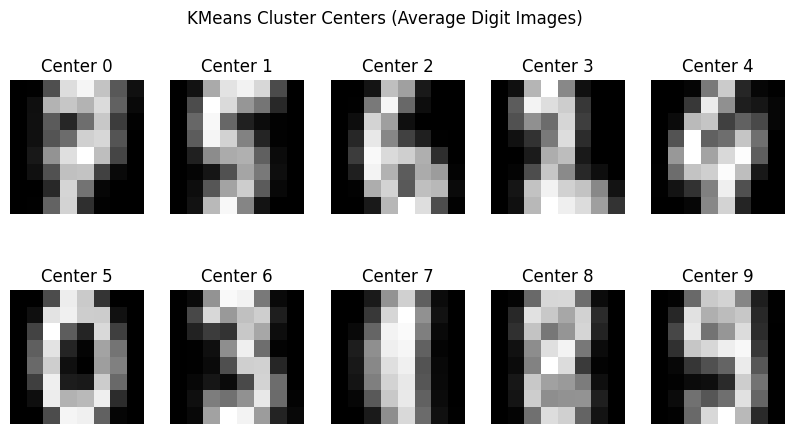

In [ ]:
# Display all 10 cluster center images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    center = kmeans.cluster_centers_[i].reshape(8, 8)  # Each center is a 64-dimensional vector, reshape to 8x8 image
    ax.imshow(center, cmap='gray')
    ax.set_title(f"Center {i}")
    ax.axis('off')

plt.suptitle("KMeans Cluster Centers (Average Digit Images)")
plt.show()


#EX2: Clustering - Recherche du paramètre k optimal
聚类 - 寻找最优的参数 k
--

1.   从练习1的代码出发，编写一个函数用于计算聚类后每个簇的**惯性（inertia）**的平均值

---
什么是惯性？

*   在 KMeans 聚类中，惯性是每个样本到其聚类中心的距离平方和，代表了聚类的紧密程度。

*   惯性越小，表示样本距离中心越近，聚类效果越好

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
import numpy as np
def calculer_inertie(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    return kmeans.inertia_



---
2. 将该函数泛化为一段代码：
    1. 横轴表示 KMeans 聚类中使用的簇数量 k
    2. 纵轴表示对应的惯性（inertia）值
    
---

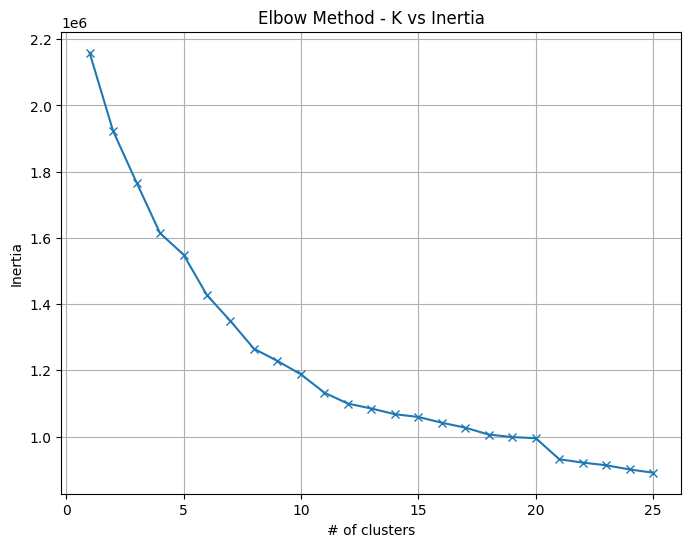

In [ ]:
import matplotlib.pyplot as plt

# 加载手写数字数据集
digits = load_digits()
X = digits.data

# 尝试不同的k值（从1到25）
k_values = range(1, 26)
inertias = []

for k in k_values:
    inertia = calculer_inertie(X, k)
    inertias.append(inertia)

# 绘制图像
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, marker='x', linestyle='-')
plt.xlabel("# of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method - K vs Inertia")
plt.grid(True)
plt.show()


3. 重复第2问的工作，但这次计算的是每个聚类的distortion（失真度）

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt
import numpy as np

# 加载数据集
digits = load_digits()
X = digits.data

# 用来保存 distortion 值
distortions = []
k_values = range(1, 26)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # 获取每个点到其最近中心点的距离
    _, distances = pairwise_distances_argmin_min(X, kmeans.cluster_centers_)

    # distortion 是所有最小距离的平均值
    distortion = np.mean(distances)
    distortions.append(distortion)

# 绘制图像
plt.figure(figsize=(8, 5))
plt.plot(k_values, distortions, marker='o')
plt.xlabel("# of clusters")
plt.ylabel("Distortion (平均距离)")
plt.title("Elbow Method - K vs Distortion")
plt.grid(True)
plt.show()


4. 使用前面开发的算法，对以下数据集进行最优 k 值的查找
  1.   在一个使用 make_blobs 人工生成的聚类数据集
  1.   IRIS 鸢尾花数据集上
  2.   在 Kaggle 上下载的 "Experience and Salary" 数据集上





In [ ]:
from sklearn.datasets import make_blobs

# 生成人工聚类数据
X_blob, y_blob = make_blobs(n_samples=1000, centers=5, random_state=42)

# 可复用前面的 inertia 或 distortion 曲线代码来找最佳 k


In [ ]:
from sklearn.datasets import load_iris

# 加载 IRIS 鸢尾花数据集
iris = load_iris()
X_iris = iris.data

# 同样复用肘部法分析


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 加载数据
df = pd.read_csv("Salary_Data.csv")  # 假设有经验和工资两列
X_salary = df[['YearsExperience', 'Salary']].values

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_salary)

# 用 X_scaled 进行 inertia / distortion vs k 的分析